,threshold,id,tn,fp,fn,tp
63280,0.1,0,59667,4145,60,1664
63282,0.1,2,60878,3503,85,1070
63283,0.1,3,62400,1614,203,1319
63284,0.1,4,64026,1212,15,283
63285,0.1,5,60162,3256,69,2049


Balanced Accuracy at threshold 0.1: 0.9640
Precision at threshold 0.1: 0.4098
Accuracy at threshold 0.1: 0.9649
TOTAL: tp = 173103083, fp = 286762990, tn = 10055136164, fn = 191810691, ACC = 0.9553


/tmp/ipykernel_3302375/1646429875.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["pos"] = df["tp"] + df["fn"]   # actual positives, constant across thresholds
/tmp/ipykernel_3302375/1646429875.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["neg"] = df["fp"] + df["tn"]   # actual negatives, constant across thresholds


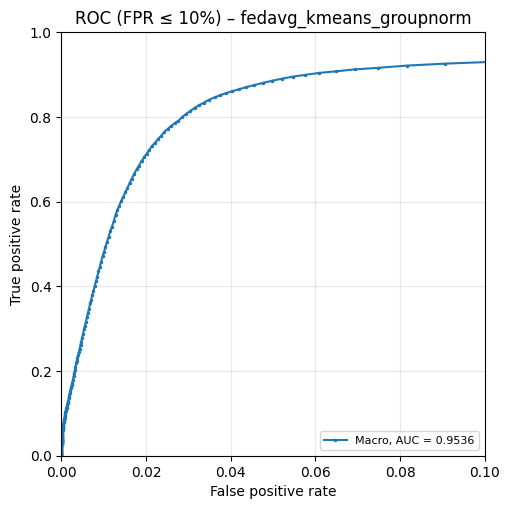

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


csv_file = "work_dirs/RouteNet_N28_biased_loss/roc_prc.csv"

df = pd.read_csv(csv_file, header=None, names=["threshold", "id", "tn", "fp", "fn", "tp"])


t = df

no_negatives      = (t["fp"] == 0) & (t["tn"] == 0)
no_positives      = (t["tp"] == 0) & (t["fn"] == 0)
no_pred_positives = (t["tp"] == 0) & (t["fp"] == 0)
df = t[~(no_negatives | no_positives | no_pred_positives)]

df_filtered = df[df["threshold"] == 0.1].copy()

display(df_filtered.head())

df_filtered['accuracy'] = (df_filtered['tp'] + df_filtered['tn']) / (df_filtered['tp'] + df_filtered['tn'] + df_filtered['fp'] + df_filtered['fn'])
balanced_accuracy = (df_filtered['tp'].sum() / (df_filtered['tp'].sum() + df_filtered['fn'].sum()) + df_filtered['tn'].sum() / (df_filtered['tn'].sum() + df_filtered['fp'].sum())) / 2
print(f"Balanced Accuracy at threshold 0.1: {balanced_accuracy:.4f}")

precision = df_filtered['tp'].sum() / (df_filtered['tp'].sum() + df_filtered['fp'].sum())
print(f"Precision at threshold 0.1: {precision:.4f}")

print(f"Accuracy at threshold 0.1: {df_filtered['accuracy'].mean():.4f}")
print(f"TOTAL: tp = {df['tp'].sum()}, fp = {df['fp'].sum()}, tn = {df['tn'].sum()}, fn = {df['fn'].sum()}, ACC = {(df['tp'].sum() + df['tn'].sum()) / (df['tp'].sum() + df['tn'].sum() + df['fp'].sum() + df['fn'].sum()):.4f}")

# ---------- ROC curve ----------
df["pos"] = df["tp"] + df["fn"]   # actual positives, constant across thresholds
df["neg"] = df["fp"] + df["tn"]   # actual negatives, constant across thresholds

# Macro: per-sample TPR/FPR, averaged over samples at each threshold
valid = df[(df["pos"] > 0) & (df["neg"] > 0)].copy()
valid["tpr"] = valid["tp"] / valid["pos"]
valid["fpr"] = valid["fp"] / valid["neg"]
valid["tnr"] = valid["tn"] / valid["neg"]
macro = valid.groupby("threshold")[["fpr", "tpr"]].mean()

def roc_points_and_auc(roc):
    # High -> low threshold gives increasing FPR; pin the (0,0) and (1,1) endpoints
    r = roc.sort_index(ascending=False)
    fpr = np.r_[0.0, r["fpr"].to_numpy(), 1.0]
    tpr = np.r_[0.0, r["tpr"].to_numpy(), 1.0]
    auc = np.sum(np.diff(fpr) * (tpr[1:] + tpr[:-1]) / 2)  # trapezoidal rule
    return fpr, tpr, auc

fpr_ma, tpr_ma, auc_ma = roc_points_and_auc(macro)

FPR_MAX = 0.10

def partial_auc(fpr, tpr, fpr_max):
    # Trapezi fino a fpr_max, con il punto finale interpolato esattamente a fpr_max
    tpr_cut = np.interp(fpr_max, fpr, tpr)
    mask = fpr <= fpr_max
    f = np.r_[fpr[mask], fpr_max]
    t = np.r_[tpr[mask], tpr_cut]
    return np.sum(np.diff(f) * (t[1:] + t[:-1]) / 2)

pauc_ma = partial_auc(fpr_ma, tpr_ma, FPR_MAX)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot(fpr_ma, tpr_ma, marker=".", markersize=3,
        label=f"Macro, AUC = {auc_ma:.4f}")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title(f"ROC (FPR ≤ {FPR_MAX:.0%}) – fedavg_kmeans_groupnorm")
ax.set_xlim(0, FPR_MAX)
ax.set_ylim(0, 1)
ax.set_box_aspect(1)
ax.grid(alpha=0.3)
ax.legend(loc="lower right", fontsize=8)
plt.show()


